 1. INSTALL LIBRARY

In [ ]:
!pip install Sastrawi openpyxl -q

2. MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

4. LOAD DATASET DARI GOOGLE DRIVE

In [ ]:
train_path = '/content/drive/MyDrive/SATRIA DATA/case_1_labeled_data.xlsx'
test_path = '/content/drive/MyDrive/SATRIA DATA/case_1_text_to_predict.xlsx'
template_path = '/content/drive/MyDrive/SATRIA DATA/case_1_template_sheet.xlsx'

5. MEMBACA DATASET

In [ ]:
train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

6. MENAMPILKAN DATA TRAIN DAN TEST

In [ ]:
print("TRAIN DATA")
print(train_df.head())

print("\nTEST DATA")
print(test_df.head())

TRAIN DATA
                                           full_text             label
0  @ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...  Sasaran Penerima
1  MBG bentuk penggarongan duit negara secara TSM...           Politik
2  @inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...  Sasaran Penerima
3  Makan Bergizi Gratis bikin masyarakat ngerasa ...  Sasaran Penerima
4  @OniSuryaman Presiden ngotot, paling sebel kal...           Politik

TEST DATA
        id                                          full_text
0  TXT0001  @yeahhhmaybe mbg di sekolah kota saya belum ad...
1  TXT0002  @thefineshytguy WKWKKdidaerah ku pun yg dapat ...
2  TXT0003  @ARSIPAJA Tai tau enggak ,gak semua sekolah da...
3  TXT0004  Gencar Cegah Stunting, MBG Telah Capai 49% Sas...
4  TXT0005    140 siswa kupang Keracunan program MBG @prabowo


7. CEK NAMA KOLOM DATASET

In [ ]:
print("\nKolom Train:")
print(train_df.columns)

print("\nKolom Test:")
print(test_df.columns)


Kolom Train:
Index(['full_text', 'label'], dtype='object')

Kolom Test:
Index(['id', 'full_text'], dtype='object')


8. MENENTUKAN NAMA KOLOM

In [ ]:
TEXT_COLUMN = 'full_text'
LABEL_COLUMN = 'label'

 9. CEK MISSING VALUE

In [ ]:
print("\nMissing Value Train")
print(train_df.isnull().sum())

print("\nMissing Value Test")
print(test_df.isnull().sum())


Missing Value Train
full_text    0
label        0
dtype: int64

Missing Value Test
id           0
full_text    0
dtype: int64


10. MENGHAPUS DATA KOSONG

In [ ]:
train_df = train_df.dropna()
test_df = test_df.dropna()


11. MENAMPILKAN JUMLAH DATA

In [ ]:
print("\nJumlah Data Train :", len(train_df))
print("Jumlah Data Test :", len(test_df))


Jumlah Data Train : 5000
Jumlah Data Test : 1500


12. MEMBUAT STOPWORD

In [ ]:
stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()


13. MEMBUAT STEMMER

In [ ]:
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

14. MEMBUAT FUNCTION CLEANING TEXT

In [ ]:
def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # hapus url
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # hapus spasi berlebih
    text = text.strip()

    # tokenisasi
    words = text.split()

    # hapus stopword
    words = [word for word in words if word not in stopwords]

    # stemming
    words = [stemmer.stem(word) for word in words]

    return ' '.join(words)


15. PREPROCESSING DATA TRAIN

In [ ]:
print("\nCleaning Train Data...")

train_df['clean_text'] = train_df[TEXT_COLUMN].apply(clean_text)


Cleaning Train Data...


16. PREPROCESSING DATA TEST

In [ ]:
print("Cleaning Test Data...")

test_df['clean_text'] = test_df[TEXT_COLUMN].apply(clean_text)

Cleaning Test Data...


17. MENAMPILKAN HASIL CLEANING

In [ ]:
print("\nHasil Cleaning:")
print(train_df[['clean_text']].head())


Hasil Cleaning:
                                          clean_text
0  pret sekolah gw dapet mbg tetep aja anakanakny...
1  mbg bentuk garong duit negara tsm terstrukturm...
2  pasal ayat undangundang dasar negara republik ...
3  makan gizi gratis bikin masyarakat ngerasa dip...
4  presiden ngotot paling sebel kalau mbg kritik ...


18. TF-IDF VECTORIZATION

In [ ]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

19. FIT DAN TRANSFORM TF-IDF

In [ ]:
X = tfidf.fit_transform(train_df['clean_text'])

y = train_df[LABEL_COLUMN]

20. SPLIT DATA TRAIN DAN VALIDASI

In [ ]:
X_test_final = tfidf.transform(test_df['clean_text'])

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

21. MEMBUAT MODEL LOGISTIC REGRESSION

In [ ]:
model = LogisticRegression(
    C=1.5,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)


22. TRAINING MODEL

In [ ]:
print("\nTraining Logistic Regression Model...")

model.fit(X_train, y_train)


Training Logistic Regression Model...


LogisticRegression(C=1.5, class_weight='balanced', max_iter=5000,
                   random_state=42)

23. PREDIKSI DATA VALIDASI

In [ ]:
valid_pred = model.predict(X_valid)

24. EVALUASI MODEL

In [ ]:
score = balanced_accuracy_score(y_valid, valid_pred)

print("\nAccuracy Score:")
print(score)

print("\nClassification Report:")
print(classification_report(y_valid, valid_pred))


Accuracy Score:
0.632790404984757

Classification Report:
                  precision    recall  f1-score   support

        Anggaran       0.70      0.72      0.71       145
      Distribusi       0.64      0.69      0.66        87
         Ekonomi       0.66      0.79      0.72        29
 Kualitas Pangan       0.75      0.68      0.71       249
         Lainnya       0.46      0.58      0.51       128
         Politik       0.55      0.47      0.51       159
Sasaran Penerima       0.56      0.58      0.57       101
     Tata Kelola       0.58      0.55      0.56       102

        accuracy                           0.62      1000
       macro avg       0.61      0.63      0.62      1000
    weighted avg       0.63      0.62      0.62      1000



25. MENAMPILKAN CONFUSION MATRIX

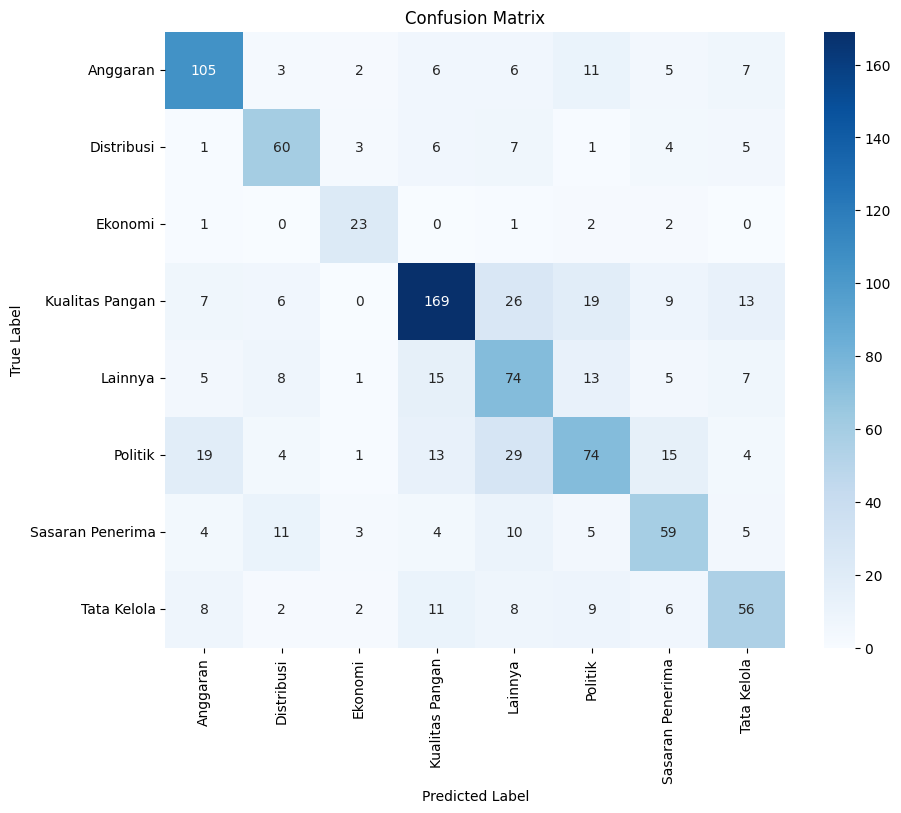

In [ ]:
cm = confusion_matrix(y_valid, valid_pred)

labels = sorted(y.unique())

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

26. TRAINING FULL DATA

In [ ]:
print("\nTraining Full Data...")

model.fit(X, y)


Training Full Data...


LogisticRegression(C=1.5, class_weight='balanced', max_iter=5000,
                   random_state=42)

27. PREDIKSI DATA TEST

In [ ]:
print("\nPredicting Test Data...")

test_pred = model.predict(X_test_final)

print("\nContoh Prediksi:")
print(test_pred[:20])


Predicting Test Data...

Contoh Prediksi:
['Distribusi' 'Politik' 'Kualitas Pangan' 'Sasaran Penerima'
 'Kualitas Pangan' 'Sasaran Penerima' 'Sasaran Penerima' 'Ekonomi'
 'Kualitas Pangan' 'Tata Kelola' 'Kualitas Pangan' 'Lainnya' 'Lainnya'
 'Sasaran Penerima' 'Ekonomi' 'Kualitas Pangan' 'Kualitas Pangan'
 'Anggaran' 'Kualitas Pangan' 'Lainnya']


28. LOAD TEMPLATE SUBMISSION

In [ ]:
submission = pd.read_excel(template_path)

29. MEMASUKKAN HASIL PREDIKSI

In [ ]:
submission['label'] = test_pred

30. MENYIMPAN FILE SUBMISSION

In [ ]:
output_path = '/content/drive/MyDrive/tim_evalta_satriadata.xlsx'

submission.to_excel(output_path, index=False)

print("\nSubmission berhasil disimpan!")

print("\nLokasi File:")
print(output_path)


Submission berhasil disimpan!

Lokasi File:
/content/drive/MyDrive/tim_evalta_satriadata.xlsx


31. DOWNLOAD FILE SUBMISSION

In [ ]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>